# Segment support on a rhizotron scan

The skeleton and segment-support steps of

> Munoz et al. (2026) *Low-cost rhizotron imaging and zero-shot deep-learning segmentation resolve temporal, spatial, and genetic variation in grapevine rootstock root systems.* bioRxiv, doi:10.64898/2026.09.10.750709

on one image: rhizotron ArUco 109 at 24 days after transplanting, the Figure S3 case, with the BiRefNet mask at threshold 0.3.

In [1]:
import os, sys, time
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('..'))
from rootsupport import mask_to_segments, SkeletonParams, trace_paths, support_counts, summarize_support, plot_support_map, plot_overlay

ARUCO, DATE = '109', '2025-04-07'  # or '2025-04-21' (38 DAT)
scan_path = f'data/aruco_{ARUCO}_date_{DATE}_aligned.jpg'
mask_path = f'data/aruco_{ARUCO}_date_{DATE}_mask.png'
image = cv2.cvtColor(cv2.imread(scan_path), cv2.COLOR_BGR2RGB)
print(image.shape)

(4230, 3346, 3)


## 1. Scan and mask

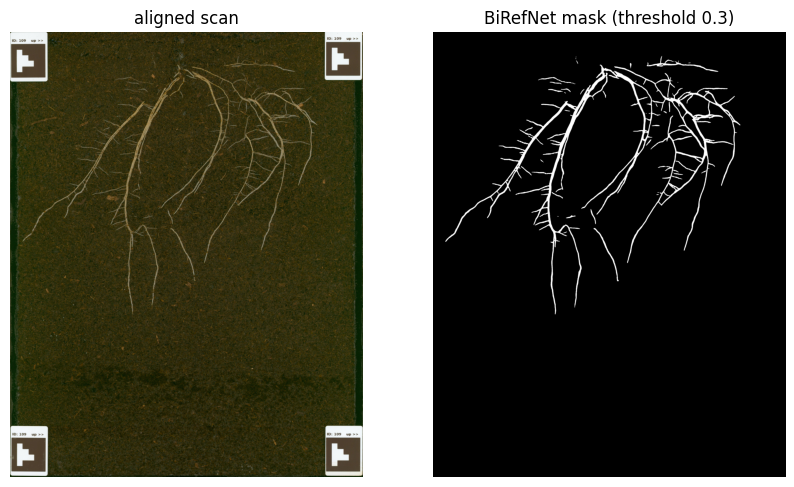

In [2]:
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(image); ax[0].set_title('aligned scan'); ax[0].set_axis_off()
ax[1].imshow(mask, cmap='gray'); ax[1].set_title('BiRefNet mask (threshold 0.3)'); ax[1].set_axis_off()
plt.show()

## 2. Skeleton and segments

The mask is smoothed (3x3 Gaussian blur and closing), skeletonized, pruned of spurs shorter than 50 pixels and cut at branch points into segments (PlantCV). Each segment end is `TIP` (free end of the skeleton) or `INNER` (cut at a branch point).

A segment with one tip is terminal, with two tips isolated, with none inner.

In [3]:
t0 = time.time()
skeleton, segment_objects, seg_info, df = mask_to_segments(mask)
print(f'{len(df)} segments in {time.time() - t0:.0f} s')
df['class'] = np.select([(df.type_1 == 'TIP') & (df.type_2 == 'TIP'), (df.type_1 == 'TIP') ^ (df.type_2 == 'TIP')],
                        ['isolated', 'terminal'], default='inner')
print(df['class'].value_counts().to_dict())
df.head()

313 segments in 47 s
{'inner': 204, 'terminal': 87, 'isolated': 22}


,seg_id,x_1,y_1,type_1,x_2,y_2,type_2,geodesic_len,euclidean_len,orientation_deg,orientation_0_90_deg,class
0,0,1160.0,1990.0,INNER,1157.0,2046.0,TIP,57,56.0,93.1,86.9,terminal
1,1,1163.0,1988.0,INNER,1198.0,1994.0,TIP,37,36.0,9.7,9.7,terminal
2,2,1156.0,1982.0,INNER,1160.0,1986.0,INNER,6,6.0,45.0,45.0,inner
3,3,1152.0,1982.0,INNER,1157.0,2687.0,TIP,739,705.0,89.6,89.6,terminal
4,4,1199.0,1908.0,INNER,1269.0,1941.0,TIP,86,77.0,25.2,25.2,terminal


## 3. Tip-initiated paths and support

The Note S1 procedure with the paper's parameters: from the tip of every terminal segment a path is traced inward, taking at each branch point the segment with the smallest turning angle (at most 100 degrees) among those not yet on the path and not descending more than 10 px. Segment ends within 15 px count as one vertex.

Support of a segment is the number of paths through it: 1 on terminal segments, the number of tips served on shared axes, 0 where no path went (isolated segments, and the bridges where two roots cross).

In [4]:
t0 = time.time()
paths, seg_to_paths, path_info = trace_paths(seg_info)
support = support_counts(seg_info, seg_to_paths)
df['support_count'] = df['seg_id'].map(support).astype(int)
print(f'{len(paths)} paths traced in {time.time() - t0:.1f} s; support range 0..{df.support_count.max()}')
df.groupby('class')['support_count'].describe()[['count', 'min', 'mean', 'max']]

87 paths traced in 0.0 s; support range 0..19


,count,min,mean,max
class,,,,
inner,204.0,0.0,3.083333,19.0
isolated,22.0,0.0,0.000000,0.0
terminal,87.0,1.0,1.000000,1.0


### Image-level summaries

Length-weighted summaries per image; `transport_root_fraction` is the share of root length with support >= 2.

In [5]:
pd.Series(summarize_support(df)).round(3)

total_length_px                 31830.000
n_segments                        313.000
mean_support_length_weighted        1.972
transport_root_fraction             0.212
share_support_0                     0.260
share_support_1                     0.528
share_isolated                      0.080
share_support_0_connected           0.179
max_support                        19.000
dtype: float64

## Figures

Segments coloured by support on a log scale (support 0 in grey), line width growing with support; open circles are tips, filled circles vertices. The window is the 3.8 x 3.8 cm region of Figure S3.

The whole-scan panel uses a 5x5 closing kernel instead of the paper's 3x3. With 3x3 on this image two junctions get cut by the 15 px vertex merge, so the traffic of the left root and of the main axis stops short of the cutting. The window panels, the tables and the check below keep the paper's parameters.

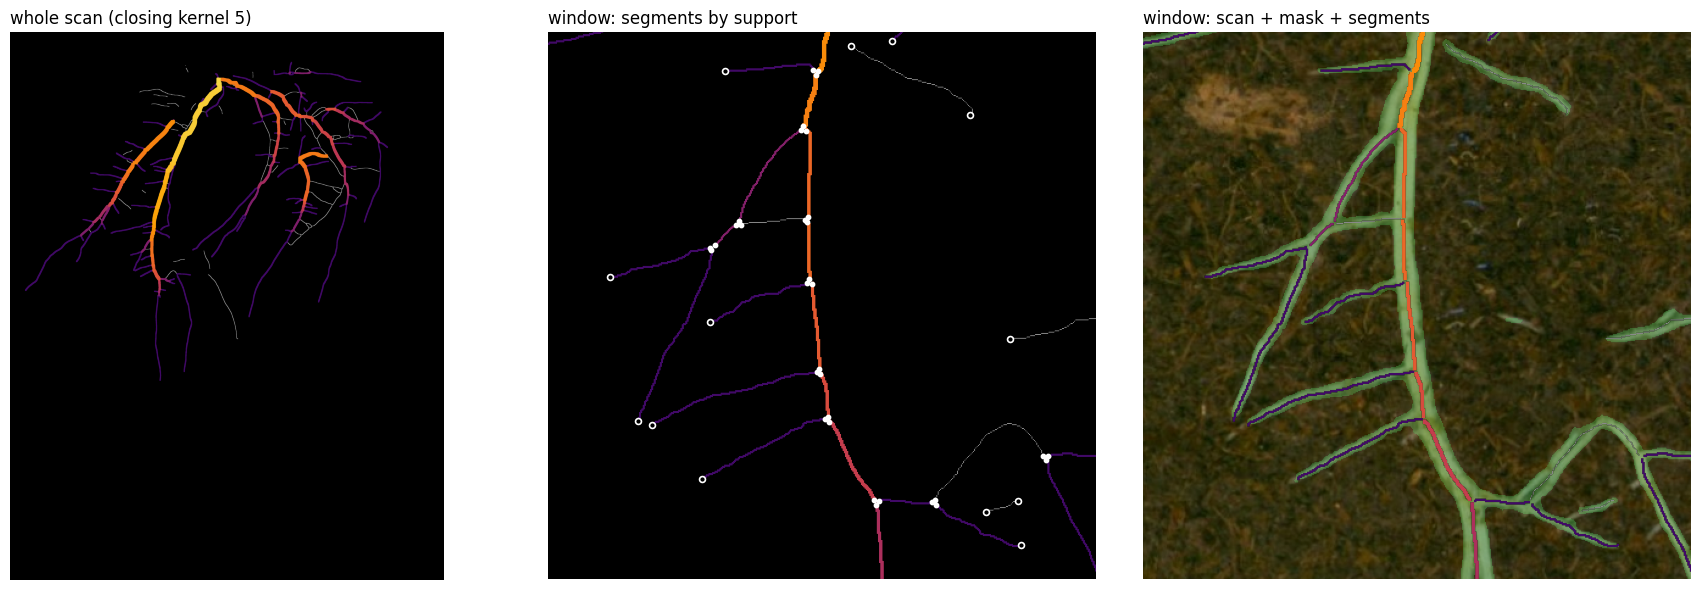

In [6]:
x0, y0, size = 880, 1520, 450
skeleton5, segment_objects5, seg_info5, _ = mask_to_segments(mask, SkeletonParams(close_kernel=5))  # whole-scan panel only
_, seg_to_paths5, _ = trace_paths(seg_info5)
support5 = support_counts(seg_info5, seg_to_paths5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_support_map(skeleton5, segment_objects5, support5, ax=axes[0], title='whole scan (closing kernel 5)')
plot_support_map(skeleton, segment_objects, support, df, window=(x0, y0, size), ax=axes[1], title='window: segments by support')
plot_overlay(image, mask, skeleton, segment_objects, support, window=(x0, y0, size), ax=axes[2], title='window: scan + mask + segments')
plt.tight_layout(); plt.show()

## Check against the paper's table

Fingerprint of the table computed for the paper, from `tests/expected/`. Same hash, same table.

In [7]:
import json
sys.path.insert(0, os.path.abspath('../tests'))
from test_reproduce_paper_tables import fingerprint
exp = json.load(open(f'../tests/expected/aruco_{ARUCO}_date_{DATE}_fingerprint.json'))
got = fingerprint(df.drop(columns=['class']))
print('segments: recomputed', got['n_segments'], '| paper', exp['n_segments'])
print('support histogram identical:', got['support_histogram'] == exp['support_histogram'])
print('table hash identical:', got['sha256_of_table'] == exp['sha256_of_table'])

segments: recomputed 313 | paper 313
support histogram identical: True
table hash identical: True


## Save

Per-segment table, same format as the paper's data files.

In [8]:
os.makedirs('output', exist_ok=True)
out = f'output/aruco_{ARUCO}_date_{DATE}_segments_support.csv'
df.drop(columns=['class']).to_csv(out, index=False); print('wrote', out)

wrote output/aruco_109_date_2025-04-07_segments_support.csv
